In [1]:
import numpy as np
from matplotlib import pyplot as plt
import h5py
from astropy import units as u

## Simulate a simple source population

Using the popsynth package, it is easy to simulate realistic cosmological populations. We can then use this as a starting point for our usual simulation of neutrinos via Stan.

In [2]:
import popsynth
from popsynth.distributions.delta_distribution import DeltaDistribution
from popsynth.distributions.pareto_distribution import ParetoDistribution
from popsynth.distributions.cosmological_distribution import SFRDistribution
from popsynth.selection_probability.flux_selectors import HardFluxSelection
from popsynth.aux_samplers.delta_aux_sampler import DeltaAuxSampler
from popsynth.aux_samplers.normal_aux_sampler import NormalAuxSampler
from popsynth.population_synth import PopulationSynth

First, choose a luminosity function and cosmological evolution.

Text(0, 0.5, '$\\dd{N}/\\dd{V} [\\si{\\giga\\parsec}^{-3}]$')

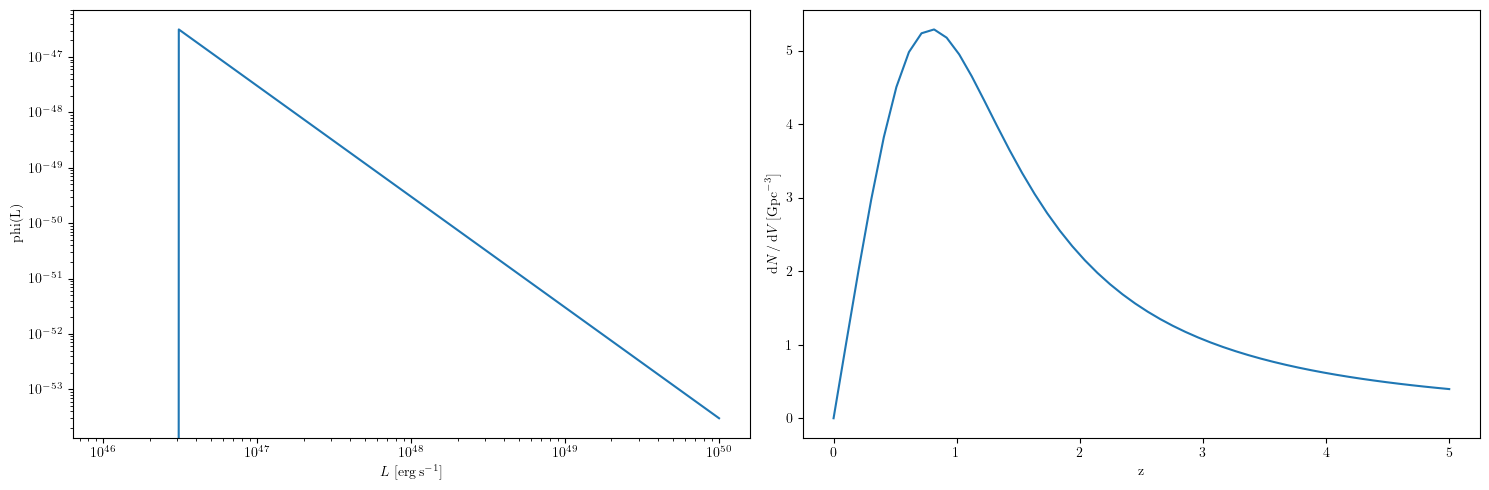

In [3]:
# All same luminosity
# lf = DeltaDistribution()
# lf.Lp = 1e47 # erg s^-1

# Power-law LF
lf = ParetoDistribution()
lf.Lmin = 3e46  # erg s^-1
lf.alpha = 1

# SFR-like distribution
sd = SFRDistribution()
sd.r0 = 10  # Gpc^-3 sr
sd.a = 0.0
sd.rise = 1.0
sd.decay = 3.0
sd.peak = 1.0

# Plot the LF and SFR-like distribution
z = np.linspace(0, 5)
L = np.geomspace(1e46, 1e50)
fig, ax = plt.subplots(1, 2)
fig.set_size_inches((15, 5))
ax[0].plot(L, lf.phi(L))
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$L~[\si{\erg\per\second}]$")
ax[0].set_ylabel("phi(L)")
ax[1].plot(z, sd.dNdV(z))
ax[1].set_xlabel("z")
ax[1].set_ylabel(r"$\dd{N}/\dd{V} [\si{\giga\parsec}^{-3}]$")

In [4]:
# Make a popsynth object using the luminosity function and evolution
pop_synth = PopulationSynth(sd, lf)

# Add a selection on the detected fluxes
flux_select = HardFluxSelection()
flux_select.boundary = 2e-10  # erg s^-1 cm^-2
pop_synth.set_flux_selection(flux_select)

# Add auxiliary sampler for spectral index
# NB: We have to use the name "spectral_index" here for this
# parameter to be recognised when loading later.

# Spectral indices all the same
# index = DeltaAuxSampler(name="spectral_index", observed=False)
# index.xp = 2.0

# Spectral indices ~ Gaussian distribution
index = NormalAuxSampler(name="spectral_index", observed=False)
index.mu = 2.0
index.tau = 0.1

pop_synth.add_observed_quantity(index)

pop_synth.display()

## Luminosity Function

<IPython.core.display.Math object>

,parameter,value
0,Lmin,3.000000e+46
1,alpha,1.000000e+00


## Spatial Function

<IPython.core.display.Math object>

,parameter,value
0,r0,10.0
1,a,0.0
2,rise,1.0
3,decay,3.0
4,peak,1.0


## spectral_index

,parameter,value
0,mu,2.0
1,tau,0.1


 INFO     |  The volume integral is 122.51907513955257 


Drawing distances:   0%|          | 0/118 [00:00<?, ?it/s]

 INFO     |  Expecting 118 total objects 
 INFO     |  Sampling: spectral_index 
 INFO     |  applying selection to fluxes 
 INFO     |  Detected 5 distances 
 INFO     |  Detected 5 objects out to a distance of 1.91 


/tmp/ipykernel_1519975/2611242955.py:4: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  population = pop_synth.draw_survey(


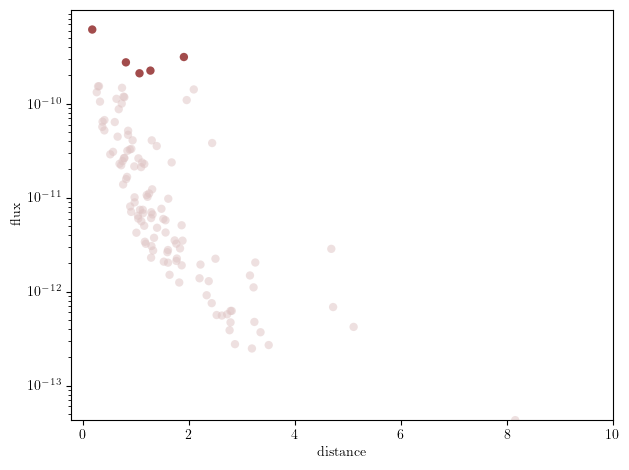

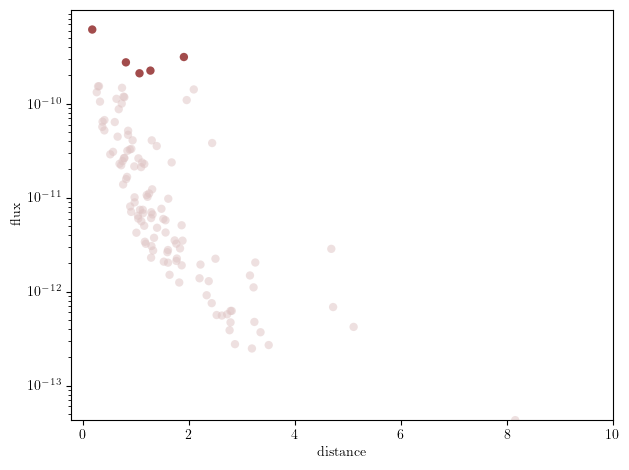

In [5]:
# Use the population synth to simulate a population
popsynth.update_logging_level("INFO")
pop_synth._seed = 42
population = pop_synth.draw_survey(
    flux_sigma=0.1,
)
population.display_fluxes()

Text(0.5, 0, 'spectral_index')

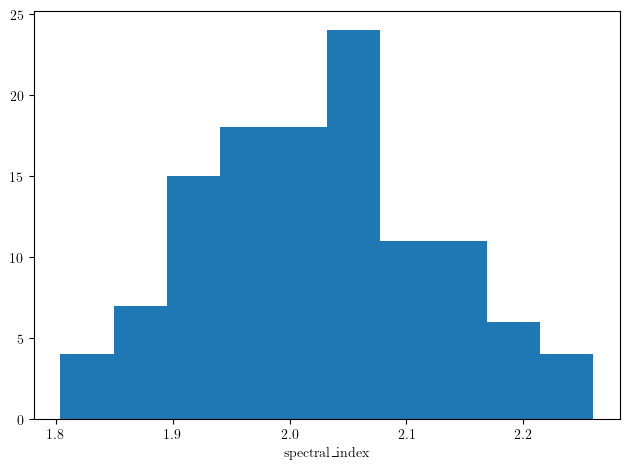

In [6]:
fig, ax = plt.subplots()
ax.hist(population.spectral_index)
ax.set_xlabel("spectral_index")

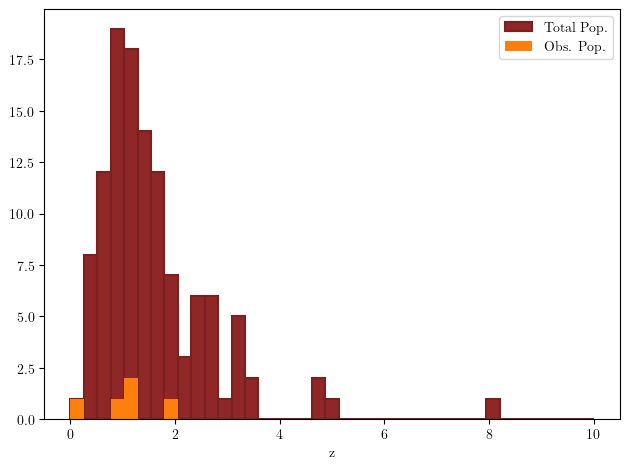

In [7]:
population.display_distances()

## Saving the population

We can save and load both the population synthesis and the sampled population as required.

In [8]:
# Population synthesis
pop_synth.write_to("output/test_pop_synth.yaml")
new_pop_synth = pop_synth.from_file("output/test_pop_synth.yaml")
new_pop_synth.display()

 INFO     |  registering auxilary sampler: spectral_index 


## Luminosity Function

<IPython.core.display.Math object>

,parameter,value
0,Lmin,3.000000e+46
1,alpha,1.000000e+00


## Spatial Function

<IPython.core.display.Math object>

,parameter,value
0,a,0.0
1,decay,3.0
2,peak,1.0
3,r0,10.0
4,r_max,10.0
5,rise,1.0


## spectral_index

,parameter,value
0,mu,2.0
1,tau,0.1


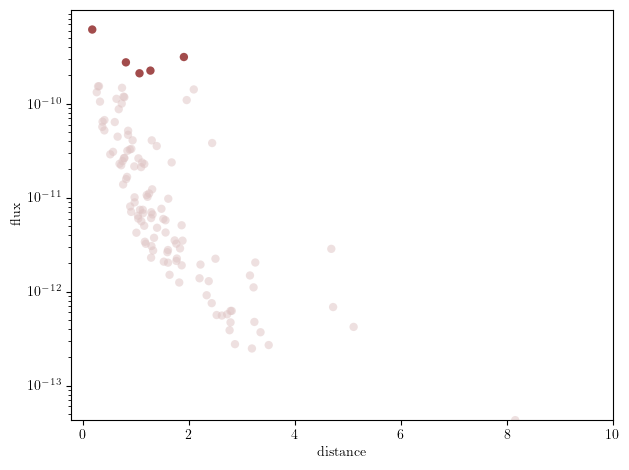

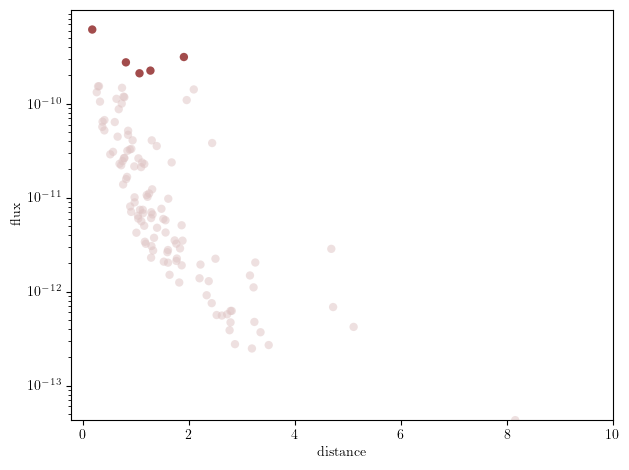

In [9]:
# Population
population.writeto("output/test_population.h5")
new_population = population.from_file("output/test_population.h5")
new_population.display_fluxes()

## Using a popsynth population to define a Sources object

In [10]:
import h5py
from astropy import units as u
from hierarchical_nu.source.parameter import Parameter
from hierarchical_nu.source.source import PointSource, Sources, DetectorFrame
from hierarchical_nu.detector.input import mceq

In [11]:
# Dfine some high-level params
Parameter.clear_registry()

# Define the bounds used to define the luminosity
Emin = Parameter(1e4 * u.GeV, "Emin", fixed=True)
Emax = Parameter(1e8 * u.GeV, "Emax", fixed=True)

Emin_diff = Parameter(Emin.value, "Emin_diff", fixed=True)
Emax_diff = Parameter(Emax.value, "Emax_diff", fixed=True)

Emin_src = Parameter(Emin.value, "Emin_src", fixed=True)
Emax_src = Parameter(Emax.value, "Emax_src", fixed=True)

# Detection thresholds
Emin_det = Parameter(1e5 * u.GeV, "Emin_det", fixed=True)


# For diffuse comp
diffuse_norm = Parameter(
    1e-13 / u.GeV / u.m**2 / u.s, "diffuse_norm", fixed=True, par_range=(0, np.inf)
)
Enorm = Parameter(1e5 * u.GeV, "Enorm", fixed=True)
diff_index = Parameter(2.5, "diff_index", fixed=False, par_range=(1, 4))


# NB: if you set L and src_index here, it will overwrite whatever is in the file
# src_index = Parameter(2.0, "src_index", fixed=False, par_range=(1, 4))
# L = Parameter(1E47 * (u.erg / u.s), "luminosity", fixed=True, par_range=(0, 1E60)*(u.erg/u.s))

In [12]:
# Make a list of point sources from the population file
point_src = PointSource.make_broken_powerlaw_sources_from_file(
    "output/test_population.h5",
    lower_energy=Emin_src,
    upper_energy=Emax_src,
    frame=DetectorFrame,
)
# NB: This will only load detected objects, unless we pass the use_undetected=True kwarg.

In [13]:
mask = np.ones(len(point_src), dtype=bool)
for c, ps in enumerate(point_src):
    mask[c] = ps.dec.to(u.deg) > -5 * u.deg

In [14]:
mask

array([ True, False,  True, False,  True])

In [15]:
# Add on to Sources object
my_sources = Sources()
my_sources.add(point_src)
my_sources.add_diffuse_component(
    diffuse_norm, Enorm.value, diff_index, Emin_diff, Emax_diff
)
my_sources.add_atmospheric_component(cache_dir=mceq)  # auto atmo component

In [18]:
my_sources.select(mask, True)

In [19]:
my_sources.sources

In [20]:
my_sources.f_arr()

<Quantity 0.00678257>

In [21]:
my_sources.point_source[2].dec.to(u.deg)

<Quantity 30.86622903 deg>

In [22]:
my_sources.sources[0].parameters

{'norm': Parameter ps_0_norm = 2.2984903394757522e-14 1 / (GeV s m2), fixed = True,
 'index': Parameter ps_0_src_index = 2.152846842641253, fixed = False}

Now that the population is simulated and loaded, the simluation and fitting proceeds largely the same as before. If there are many point sources without neutrino signals, we may want to try using a shared luminosity or spectral index parameter, or more constrained prior distributions for these parameters in order for the results to be meaningful.